<a href="https://colab.research.google.com/github/venturaesteban/03MIAR-Algoritmos-de-Optimizaci-n/blob/main/notebooks/AG3/Ventura_Esteban_Algoritmos_AG3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#AG3 - Actividad Guiada 3
Nombre: Ventura Esteban Guerrero <br>
Link:   https://colab.research.google.com/drive/1qqgOd8ntmcRdZpPHuhaLfc5_36YJWMBv?usp=sharing <br>
Github: https://github.com/venturaesteban/03MIAR-Algoritmos-de-Optimizaci-n
<br>


#Carga de librerias

In [2]:
!pip install requests
!pip install tabulate==0.8.7
!pip install networkx==2.8.8
!pip install deprecated==1.2.9
!pip install tsplib95 --no-deps

In [3]:
!pip install deprecated

#Carga de los datos del problema

In [4]:

import urllib.request #Hacer llamadas http a paginas de la red
import tsplib95       #Modulo para las instancias del problema del TSP
import math           #Modulo de funciones matematicas. Se usa para exp
import random         #Para generar valores aleatorios


#Descargamos el fichero de datos(Matriz de distancias)
file = "swiss42.tsp" ;
#urllib.request.urlretrieve("https://raw.githubusercontent.com/mastqe/tsplib/refs/heads/master/swiss42.tsp", file + '.gz')
urllib.request.urlretrieve("https://raw.githubusercontent.com/mastqe/tsplib/refs/heads/master/swiss42.tsp", file  )
#!gzip -d swiss42.tsp.gz     #Descomprimir el fichero de datos

#Coordendas 51-city problem (Christofides/Eilon)
#file = "eil51.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/eil51.tsp.gz", file)

#Coordenadas - 48 capitals of the US (Padberg/Rinaldi)
#file = "att48.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/att48.tsp.gz", file)


#http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95
#Documentacion :
  # http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp95.pdf
  # https://tsplib95.readthedocs.io/en/stable/pages/usage.html
  # https://tsplib95.readthedocs.io/en/v0.6.1/modules.html
  # https://pypi.org/project/tsplib95/




('swiss42.tsp', <http.client.HTTPMessage at 0x7c451c801340>)

In [5]:
#Carga de datos y generación de objeto problem
###############################################################################
problem = tsplib95.load(file)

#Nodos
Nodos = list(problem.get_nodes())

#Aristas
Aristas = list(problem.get_edges())



In [ ]:
Nodos

In [ ]:
Aristas
# https://github.com/mastqe/tsplib/blob/master/swiss42.tsp


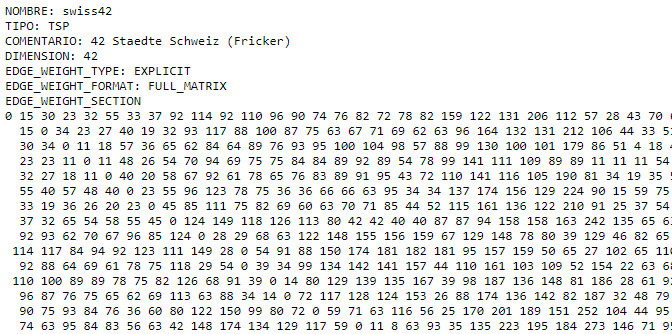

In [8]:
#Probamos algunas funciones del objeto problem

#Distancia entre nodos
problem.get_weight(5, 20)

#Todas las funciones
#Documentación: https://tsplib95.readthedocs.io/en/v0.6.1/modules.html

#dir(problem)

137

#Funcionas basicas


In [9]:

#Funcionas basicas
###############################################################################

#Se genera una solucion aleatoria con comienzo en en el nodo 0
def crear_solucion(Nodos):
  solucion = [Nodos[0]]
  for n in Nodos[1:]:
    solucion = solucion + [random.choice(list(set(Nodos) - set({Nodos[0]}) - set(solucion)))]
  return solucion

#Devuelve la distancia entre dos nodos
def distancia(a,b, problem):
  return problem.get_weight(a,b)

#Devuelve la distancia total de una trayectoria/solucion
def distancia_total(solucion, problem):
  distancia_total = 0
  for i in range(len(solucion)-1):
    distancia_total += distancia(solucion[i] ,solucion[i+1] ,  problem)
  return distancia_total + distancia(solucion[len(solucion)-1] ,solucion[0], problem)

sol_temporal = crear_solucion(Nodos)


print(sol_temporal   )
print(distancia_total(sol_temporal, problem))

[0, 39, 23, 2, 10, 9, 40, 8, 37, 26, 15, 24, 31, 21, 38, 7, 33, 6, 1, 14, 27, 34, 30, 12, 19, 4, 22, 35, 20, 32, 13, 16, 3, 17, 5, 11, 25, 18, 41, 28, 29, 36]
4394


#BUSQUEDA ALEATORIA

In [10]:
###############################################################################
# BUSQUEDA ALEATORIA
###############################################################################

def busqueda_aleatoria(problem, N):
  #N es el numero de iteraciones
  Nodos = list(problem.get_nodes())

  mejor_solucion = []
  #mejor_distancia = 10e100                         #Inicializamos con un valor alto
  mejor_distancia = float('inf')                    #Inicializamos con un valor alto

  for i in range(N):                                #Criterio de parada: repetir N veces pero podemos incluir otros
    solucion = crear_solucion(Nodos)                #Genera una solucion aleatoria
    distancia = distancia_total(solucion, problem)  #Calcula el valor objetivo(distancia total)

    if distancia < mejor_distancia:                 #Compara con la mejor obtenida hasta ahora
      mejor_solucion = solucion
      mejor_distancia = distancia


  print("Mejor solución:" , mejor_solucion)
  print("Distancia     :" , mejor_distancia)
  return mejor_solucion


#Busqueda aleatoria con 5000 iteraciones
solucion = busqueda_aleatoria(problem, 50000)

Mejor solución: [0, 17, 16, 19, 29, 4, 15, 36, 13, 12, 25, 41, 30, 26, 6, 18, 33, 2, 27, 3, 37, 10, 35, 34, 32, 24, 40, 9, 21, 39, 22, 7, 14, 5, 31, 20, 38, 28, 8, 23, 11, 1]
Distancia     : 3366


#BUSQUEDA LOCAL

In [11]:
###############################################################################
# BUSQUEDA LOCAL(1 paso)
###############################################################################
def genera_vecina(solucion):
  #Generador de soluciones vecinas: 2-opt (intercambiar 2 nodos) Si hay N nodos se generan (N-1)x(N-2)/2 soluciones
  #Se puede modificar para aplicar otros generadores distintos que 2-opt
  #print(solucion)
  mejor_solucion = []
  mejor_distancia = 10e100
  for i in range(1,len(solucion)-1):          #Recorremos todos los nodos en bucle doble para evaluar todos los intercambios 2-opt
    for j in range(i+1, len(solucion)):

      #Se genera una nueva solución intercambiando los dos nodos i,j:
      #  (usamos el operador + que para listas en python las concatena) : ej.: [1,2] + [3] = [1,2,3]
      vecina = solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]

      #Se evalua la nueva solución ...
      distancia_vecina = distancia_total(vecina, problem)

      #... para guardarla si mejora las anteriores
      if distancia_vecina <= mejor_distancia:
        mejor_distancia = distancia_vecina
        mejor_solucion = vecina
  return mejor_solucion


#solucion = [1, 47, 13, 41, 40, 19, 42, 44, 37, 5, 22, 28, 3, 2, 29, 21, 50, 34, 30, 9, 16, 11, 38, 49, 10, 39, 33, 45, 15, 24, 43, 26, 31, 36, 35, 20, 8, 7, 23, 48, 27, 12, 17, 4, 18, 25, 14, 6, 51, 46, 32]
print("Distancia Solucion Incial:" , distancia_total(solucion, problem))


nueva_solucion = genera_vecina(solucion)
print("Distancia Mejor Solucion Local:", distancia_total(nueva_solucion, problem))


Distancia Solucion Incial: 3366
Distancia Mejor Solucion Local: 3052


In [12]:
#Busqueda Local(iteraciones):
#  - Sobre el operador de vecindad 2-opt(funcion genera_vecina)
#  - Sin criterio de parada, se para cuando no es posible mejorar.
def busqueda_local(solucion, problem):
  mejor_solucion = []

  #Generar una solucion inicial de referencia(aleatoria)
  #solucion_referencia = crear_solucion(Nodos)
  solucion_referencia = solucion
  mejor_distancia = distancia_total(solucion_referencia, problem)

  iteracion=0             #Un contador para saber las iteraciones que hacemos
  while(1):
    iteracion +=1         #Incrementamos el contador
    #print('#',iteracion)

    #Obtenemos la mejor vecina ...
    vecina = genera_vecina(solucion_referencia)

    #... y la evaluamos para ver si mejoramos respecto a lo encontrado hasta el momento
    distancia_vecina = distancia_total(vecina, problem)

    #Si no mejoramos hay que terminar. Hemos llegado a un minimo local(según nuestro operador de vencindad 2-opt)
    if distancia_vecina < mejor_distancia:
      #mejor_solucion = copy.deepcopy(vecina)   #Con copia profunda. Las copias en python son por referencia
      mejor_solucion = vecina                   #Guarda la mejor solución encontrada
      mejor_distancia = distancia_vecina

    else:
      print("En la iteracion ", iteracion, ", la mejor solución encontrada es:" , mejor_solucion)
      print("Distancia     :" , mejor_distancia)
      return mejor_solucion

    solucion_referencia = vecina


sol = busqueda_local(nueva_solucion, problem )

En la iteracion  27 , la mejor solución encontrada es: [0, 14, 16, 19, 13, 5, 6, 26, 18, 12, 11, 25, 10, 8, 28, 27, 3, 4, 1, 15, 37, 20, 33, 34, 38, 22, 24, 40, 21, 39, 29, 7, 17, 36, 35, 31, 32, 30, 9, 23, 41, 2]
Distancia     : 1797


#SIMULATED ANNEALING


In [13]:
###############################################################################
# SIMULATED ANNEALING
###############################################################################

#Generador de 1 solucion vecina 2-opt 100% aleatoria (intercambiar 2 nodos)
#Mejorable eligiendo otra forma de elegir una vecina.
def genera_vecina_aleatorio(solucion):

  #Se eligen dos nodos aleatoriamente
  i,j = sorted(random.sample( range(1,len(solucion)) , 2))

  #Devuelve una nueva solución pero intercambiando los dos nodos elegidos al azar
  return solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]


#Funcion de probabilidad para aceptar peores soluciones
def probabilidad(T,d):
  if random.random() <  math.exp( -1*d / T)  :
    return True
  else:
    return False

#Funcion de descenso de temperatura
def bajar_temperatura(T):
  return T*0.99

In [14]:
def recocido_simulado(problem, TEMPERATURA ):
  #problem = datos del problema
  #T = Temperatura

  solucion_referencia = crear_solucion(Nodos)
  distancia_referencia = distancia_total(solucion_referencia, problem)

  mejor_solucion = []             #x* del seudocodigo
  mejor_distancia = 10e100        #F* del seudocodigo


  N=0
  while TEMPERATURA > .0001:
    N+=1
    #Genera una solución vecina
    vecina =genera_vecina_aleatorio(solucion_referencia)

    #Calcula su valor(distancia)
    distancia_vecina = distancia_total(vecina, problem)

    #Si es la mejor solución de todas se guarda(siempre!!!)
    if distancia_vecina < mejor_distancia:
        mejor_solucion = vecina
        mejor_distancia = distancia_vecina

    #Si la nueva vecina es mejor se cambia
    #Si es peor se cambia según una probabilidad que depende de T y delta(distancia_referencia - distancia_vecina)
    if distancia_vecina < distancia_referencia or probabilidad(TEMPERATURA, abs(distancia_referencia - distancia_vecina) ) :
      #solucion_referencia = copy.deepcopy(vecina)
      solucion_referencia = vecina
      distancia_referencia = distancia_vecina

    #Bajamos la temperatura
    TEMPERATURA = bajar_temperatura(TEMPERATURA)

  print("La mejor solución encontrada es " , end="")
  print(mejor_solucion)
  print("con una distancia total de " , end="")
  print(mejor_distancia)
  return mejor_solucion

sol  = recocido_simulado(problem, 100000000)

La mejor solución encontrada es [0, 1, 4, 5, 26, 12, 13, 19, 31, 36, 35, 33, 38, 24, 40, 21, 9, 28, 27, 2, 3, 18, 11, 25, 10, 8, 29, 30, 22, 39, 23, 41, 6, 7, 37, 15, 16, 14, 17, 34, 20, 32]
con una distancia total de 1925


#Representación en un grafo a partir de la matriz de distancias( Optimización de posiciones usando escalado multidimensional (MDS)



Multidimensional scaling problem(MDS):   https://en.wikipedia.org/wiki/Multidimensional_scaling

In [15]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import MDS  # Multidimensional Scaling o Escalado Multidimensional

def plot_tsp_solution(distance_matrix, tsp_solution):
    """
    Dibuja el grafo de un TSP con las posiciones calculadas mediante MDS y muestra
    solo las aristas correspondientes a la solución del TSP.

    :param distance_matrix: np.ndarray, matriz de distancias entre nodos
    :param tsp_solution: list, lista de nodos en el orden de la solución del TSP
    """
    # Crear el grafo completo
    G = nx.Graph()
    num_nodes = len(distance_matrix)
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            G.add_edge(i, j, weight=distance_matrix[i][j])

    # Usar MDS para calcular posiciones de los nodos
    mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
    positions = mds.fit_transform(distance_matrix)

    # Convertir las posiciones en un diccionario para networkx
    pos = {i: positions[i] for i in range(num_nodes)}

    # Crear un subgrafo con las aristas del camino TSP
    TSP_G = nx.Graph()
    for i in range(len(tsp_solution) - 1):
        u = tsp_solution[i]
        v = tsp_solution[i + 1]
        TSP_G.add_edge(u, v, weight=distance_matrix[u][v])

    # Dibujar el grafo
    plt.figure(figsize=(8, 6))

    # Dibujar nodos
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)

    # Dibujar las aristas del camino TSP
    nx.draw_networkx_edges(TSP_G, pos, edge_color='red', width=2)

    # Añadir etiquetas a los nodos y pesos de las aristas
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
    edge_labels = nx.get_edge_attributes(TSP_G, 'weight')
    nx.draw_networkx_edge_labels(TSP_G, pos, edge_labels=edge_labels, font_size=8)

    plt.title("Grafo TSP con solución específica")
    plt.show()


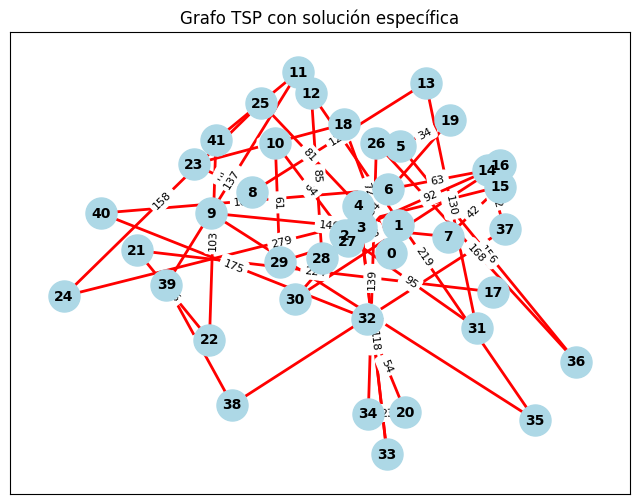

In [16]:
plot_tsp_solution(problem.edge_weights, crear_solucion(Nodos))

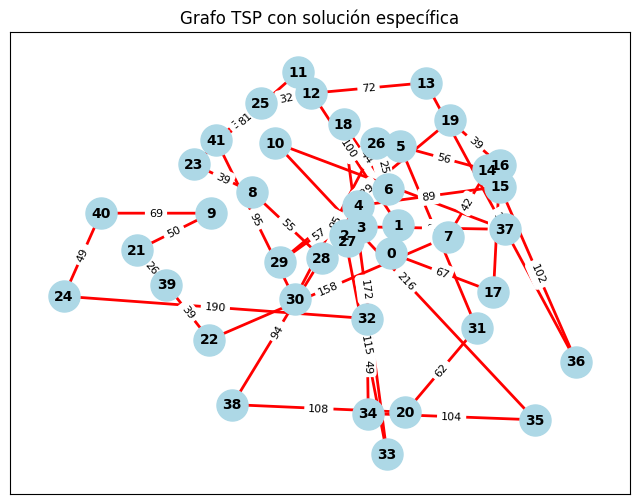

In [17]:
plot_tsp_solution(problem.edge_weights, solucion)

## Búsqueda Local con Entornos Variables

**¿Se puede mejorar con otros operadores de vecindad variables?**

La búsqueda local que implementamos antes usa solo el operador 2-opt (intercambio de 2 nodos). La idea de la **Búsqueda por Entornos Variables (VNS)** es usar varios operadores de vecindad distintos con el fin de ir probando con distintos nodos para obtener una solución diferente si con el inicial ya no se puede mejorar.

Tal y como mencionó el profesor en la clase, hemos implementado el concepto **n-opt** variando n. Usamos el operador **or-opt**, que coge un segmento de n nodos consecutivos y lo reubica en otra posición del recorrido, empezando con segmentos grandes (n=5) que hacen cambios más bruscos e ir bajando hasta n=2 que son cambios más finos. Cada vez que se encuentra una mejora, volvemos al segmento más grande (n=5).

In [18]:
def genera_vecina_or_opt(solucion, n):
  """
  Vamos a usar el operador or-opt, que coge un segmento de n nodos consecutivos
  y lo reubica en la mejor posición posible.
  Usaremos n=5 para cambios grandes y bajaremos a n=2 para cambios finos
  """
  mejor_solucion = []
  mejor_distancia = 10e100
  num_nodos = len(solucion)

  for i in range(1, num_nodos - n + 1):            # Posición del segmento a extraer (trato el nodo 0 como fijo)
    segmento = solucion[i:i+n]
    resto = solucion[:i] + solucion[i+n:]  # El recorrido sin ese segmento (que se reinsertará después)

    for j in range(1, len(resto) + 1):      # Posiciones donde reinsertar el segmento (entre nodos del resto)
      vecina = resto[:j] + segmento + resto[j:]

      distancia_vecina = distancia_total(vecina, problem)
      if distancia_vecina <= mejor_distancia:
        mejor_distancia = distancia_vecina
        mejor_solucion = vecina

  return mejor_solucion

In [19]:
def busqueda_local_VNS(solucion_inicial, problem):
  """
  Usamos varios operadores n-opt (de n=5 a n=2) + el original.
    Si un operador no mejora, pasamos al siguiente.
    Si alguno mejora, volvemos al primero (n=5) y repetimos hasta que ninguno mejore.
  """
  solucion = solucion_inicial
  mejor_distancia = distancia_total(solucion, problem)

  # Operadores ordenados de mayor a menor
  nombres = ["or-opt(5)", "or-opt(4)", "or-opt(3)", "or-opt(2)", "2-opt"]

  n = 0  # Empezamos con el primer operador (or-opt n=5)
  iteracion = 0

  while n < 5:
    iteracion += 1

    # Elegimos el operador según n
    if n < 4:
      vecina = genera_vecina_or_opt(solucion, 5 - n)
    else:
      vecina = genera_vecina(solucion)        # El último operador es el 2-opt original

    distancia_vecina = distancia_total(vecina, problem)

    if distancia_vecina < mejor_distancia:
      print(f"  Iteracion {iteracion}: Mejora con {nombres[n]} -> distancia = {distancia_vecina}")
      solucion = vecina
      mejor_distancia = distancia_vecina
      n = 0
    else:
      n += 1

  print(f"\nNúmero de {iteracion} iteraciones")
  print("Mejor solucion:", solucion)
  print("Distancia     :", mejor_distancia)
  return solucion

In [20]:
# Generamos una solución aleatoria como punto de partida común
solucion_inicial = crear_solucion(Nodos)
print("Solucion inicial, distancia:", distancia_total(solucion_inicial, problem))

# 1) Búsqueda local simple (solo 2-opt como antes)
print("Busqyeda local (2-opt)")
sol_local = busqueda_local(solucion_inicial, problem)
dist_local = distancia_total(sol_local, problem)

# 2) Búsqueda local con entornos variables (or-opt n=5 hasta n=2 + intercambios)
print("Busqueda local con entornos variables (n-opt, n=5 hasta n=2)")
sol_vns = busqueda_local_VNS(solucion_inicial, problem)
dist_vns = distancia_total(sol_vns, problem)

# Resultado
print(f"Busqueda Local:     {dist_local}")
print(f"Busqueda Local con entornos variables:        {dist_vns}")
mejora = ((dist_local - dist_vns) / dist_local) * 100
print(f"Ratio de mejora de VNS respecto a BL:            {mejora:.2f}%")

Solucion inicial, distancia: 4841
Busqyeda local (2-opt)
En la iteracion  30 , la mejor solución encontrada es: [0, 2, 27, 32, 34, 33, 20, 35, 36, 37, 15, 1, 4, 6, 14, 16, 19, 13, 41, 23, 40, 24, 21, 39, 26, 5, 7, 17, 31, 28, 29, 30, 38, 22, 9, 8, 10, 25, 11, 12, 18, 3]
Distancia     : 1813
Busqueda local con entornos variables (n-opt, n=5 hasta n=2)
  Iteracion 1: Mejora con or-opt(5) -> distancia = 4412
  Iteracion 2: Mejora con or-opt(5) -> distancia = 3959
  Iteracion 3: Mejora con or-opt(5) -> distancia = 3701
  Iteracion 4: Mejora con or-opt(5) -> distancia = 3471
  Iteracion 5: Mejora con or-opt(5) -> distancia = 3245
  Iteracion 6: Mejora con or-opt(5) -> distancia = 3038
  Iteracion 7: Mejora con or-opt(5) -> distancia = 2910
  Iteracion 8: Mejora con or-opt(5) -> distancia = 2749
  Iteracion 9: Mejora con or-opt(5) -> distancia = 2609
  Iteracion 10: Mejora con or-opt(5) -> distancia = 2506
  Iteracion 11: Mejora con or-opt(5) -> distancia = 2416
  Iteracion 12: Mejora con or

### Conclusión

Sí, podemos mejorar con operadores de vecindad variables como el descenso de vecindad variable (VND) usando el operador or-opt de n=5 hasta n=2 combinado con el 2-opt original, con este metodo estamos obteniendo mejores resultados que con la búsqueda local simple.

## Recocido Simulado

**¿Se puede mejorar con otra elección no tan aleatoria (modificando genera_vecina_aleatorio())?**

En el recocido simulado original, la función `genera_vecina_aleatorio()` elige dos nodos completamente al azar para intercambiarlos, es aquí donde podemos encontrarnos con el problema de estar moviendo nodos que ya están bien colocados y por lo tanto realizamos iteraciones sin necesidad.

La idea es hacer la selección de cada nodo guiada por el coste local, el cual calculamos como la suma de las distancias a sus dos vecinos en el recorrido. Si detectamos un nodo con coste local alto interpretaremos que está mal colocado, por lo que será más susceptible de ser intercambiado.

In [21]:
def genera_vecina_guiada(solucion):
  n = len(solucion)

  # Calculamos coste local de cada nodo (distancia al anterior y al siguiente)
  costes = []
  for i in range(n):
    prev = (i - 1) % n
    sig = (i + 1) % n
    coste = distancia(solucion[prev], solucion[i], problem) + distancia(solucion[i], solucion[sig], problem)
    costes.append(coste)

  # El nodo de inicio no lo movemos, lo dejamos fijo
  costes[0] = 0

  # Elegimos el primer nodo en base al más probable (peor colocado)
  i = random.choices(range(1, n), weights=costes[1:], k=1)[0]

  # El segundo nodo lo elegimos al azar siempre que sea diferente de i
  candidatos = [x for x in range(1, n) if x != i]
  j = random.choice(candidatos)

  if i > j:
    i, j = j, i

  nueva_solucion = solucion.copy()
  nueva_solucion[i], nueva_solucion[j] = nueva_solucion[j], nueva_solucion[i]

  return nueva_solucion

In [22]:
def recocido_simulado_mejorado(problem, TEMPERATURA):
  sol_actual = crear_solucion(Nodos)
  dist_actual = distancia_total(sol_actual, problem)

  mejor_solucion = []
  mejor_distancia = 10e100

  n = 0
  while TEMPERATURA > .0001:
    n += 1

    # usamos la funcion guiada en vez de la aleatoria
    vecina = genera_vecina_guiada(sol_actual)

    dist_vecina = distancia_total(vecina, problem)

    if dist_vecina < mejor_distancia:
      mejor_solucion = vecina
      mejor_distancia = dist_vecina

    if dist_vecina < dist_actual or probabilidad(TEMPERATURA, abs(dist_actual - dist_vecina)):
      sol_actual = vecina
      dist_actual = dist_vecina

    TEMPERATURA = bajar_temperatura(TEMPERATURA)

  print("La mejor solucion encontrada es " , end="")
  print(mejor_solucion)
  print("con una distancia total de " , end="")
  print(mejor_distancia)

  return mejor_solucion

In [23]:
temp_inicial = 100000000
n_ejecuciones = 5

print("Recocido Simulado (vecino aleatorio)")
resultados_original = []
for run in range(n_ejecuciones):
  sol_orig = recocido_simulado(problem, temp_inicial)
  resultados_original.append(distancia_total(sol_orig, problem))

print("Recocido Simulado (Vecino guiado)")
resultados_mejorado = []
for run in range(n_ejecuciones):
  sol_mej = recocido_simulado_mejorado(problem, temp_inicial)
  resultados_mejorado.append(distancia_total(sol_mej, problem))

print("Resultados:")
media_orig = sum(resultados_original) / len(resultados_original)
media_mej = sum(resultados_mejorado) / len(resultados_mejorado)
mejor_orig = min(resultados_original)
mejor_mej = min(resultados_mejorado)

print(f"Original  -> media: {media_orig:.1f}  mejor: {mejor_orig}")
print(f"Mejorado  -> media: {media_mej:.1f}  mejor: {mejor_mej}")
mejora_media = ((media_orig - media_mej) / media_orig) * 100
print(f"Mejora media: {mejora_media:.2f}%")

Recocido Simulado (vecino aleatorio)
La mejor solución encontrada es [0, 1, 15, 37, 7, 32, 31, 17, 36, 35, 27, 26, 18, 12, 25, 11, 13, 5, 19, 16, 14, 6, 2, 22, 38, 30, 28, 29, 8, 9, 40, 24, 21, 39, 33, 20, 34, 3, 4, 10, 23, 41]
con una distancia total de 2098
La mejor solución encontrada es [0, 9, 23, 41, 8, 6, 31, 35, 36, 14, 19, 13, 16, 15, 37, 17, 7, 38, 39, 24, 40, 21, 22, 3, 4, 18, 12, 25, 11, 10, 2, 27, 28, 29, 30, 33, 34, 20, 32, 26, 5, 1]
con una distancia total de 2037
La mejor solución encontrada es [0, 10, 25, 41, 23, 40, 24, 22, 38, 33, 34, 28, 30, 29, 39, 21, 9, 8, 14, 37, 15, 16, 11, 12, 32, 31, 36, 35, 20, 17, 1, 3, 2, 27, 4, 6, 19, 13, 18, 26, 5, 7]
con una distancia total de 2072
La mejor solución encontrada es [0, 6, 5, 19, 16, 37, 15, 14, 13, 7, 17, 36, 35, 31, 1, 26, 12, 18, 11, 25, 41, 23, 40, 9, 21, 24, 38, 20, 33, 34, 29, 8, 10, 4, 2, 3, 27, 28, 30, 39, 22, 32]
con una distancia total de 1923
La mejor solución encontrada es [0, 26, 6, 2, 27, 28, 29, 32, 17, 31, 5

### Conclusión

Sí, se puede mejorar el recocido simulado modificando `genera_vecina_aleatorio()`. Usando una selección guiada por el coste local evitamos que los nodos que están peor colocados tengan menos probabilidad de ser seleccionados para el intercambio. Conseguimos que los intercambios sean mejores y no se pierdan tantas iteraciones moviendo nodos que ya estaban en buena posición.